# **Task 1: End-to-End ML Project with Streamlit GUI**

### **Introduction**
Customer churn, the loss of customers over time, is a major challenge for banks and financial institutions. Retaining existing customers is often more cost-effective than acquiring new ones, making churn prediction a critical business problem. By identifying customers who are likely to leave, banks can take proactive steps to improve customer satisfaction, optimize retention strategies, and reduce revenue loss.

> This project focuses on building a complete end-to-end machine learning system to predict customer churn using a banking dataset. The project includes all major steps of a machine learning workflow such as data preprocessing, model training, model evaluation, and model selection.

Multiple machine learning algorithms are trained and compared, including **Logistic Regression, Random Forest, and XGBoost**, and the best-performing model is saved and integrated into a user-friendly GUI for real-time predictions. 

The final outcome is not only a strong predictive model, but also a **deployable AI application** that allows users to input customer details and instantly receive churn predictions along with confidence probabilities and visual insights.



### **Problem Statement**

The primary problem addressed in this project is:

* **To predict whether a bank customer will churn (leave) or remain**, based on demographic, financial, and account activity information.

Accurate churn prediction enables banks to identify high-risk customers early and take targeted actions to improve retention.

### **Objectives**
The objectives of this project are to build an end-to-end machine learning system for customer churn prediction, perform data preprocessing and exploratory analysis, train and compare multiple classification models, and deploy the best-performing model using a Streamlit-based graphical user interface


### **Dataset Overview**

The dataset contains information for **10,000 bank customers**, including:

* **Demographic features:** Age, Gender, Geography
* **Financial features:** CreditScore, Balance, EstimatedSalary, NumOfProducts
* **Account activity features:** Tenure, IsActiveMember, HasCrCard
* **Target variable:**

  * `Exited` 1 = customer churned, 
             0 = customer retained


### **Project Workflow**

This project follows a structured, end-to-end machine learning pipeline:

1. **Data Loading and Understanding**

   * Load the dataset and inspect its structure and contents
   * Remove irrelevant or unimportant columns

2. **Exploratory Data Analysis (EDA)**

   * Analyze feature distributions and relationships
   * Identify patterns related to customer churn

3. **Data Preprocessing**

   * Encode categorical variables
   * Scale numerical features
   * Split the dataset into training and testing sets

4. **Model Training**

   * Train multiple machine learning models, including Logistic Regression, SVM, Random Forest, Gradient Boosting, and XGBoost

5. **Model Evaluation and Comparison**

   * Evaluate each model using accuracy, confusion matrix, and classification report
   * Compare model performance using a consolidated results DataFrame
   * Rank models based on performance metrics

6. **Model Selection and Saving**

   * Select the best-performing model
   * Save the trained model using `joblib` or `pickle`

7. **Streamlit Application Development**

   * Develop an interactive Streamlit interface for predictions
   * Display prediction results, probabilities, model accuracy, and feature importance


### **Outcome**

By the end of this task, the project delivers:

* A complete **end-to-end ML pipeline**
* A **trained and saved predictive model**
* A **Streamlit-based GUI** for real-time customer churn prediction
* Practical experience in deploying machine learning models as interactive applications











### **Importing Libraries**


In [61]:
# analysis
import pandas as pd
import numpy as np


# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# for preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report




import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')


### **Data Loading and Understanding**

In [62]:

# load the  dataset
file_path = './dataset/Churn_Modelling.csv' 
df = pd.read_csv(file_path)

Let's view a few rows from the dataset.

In [63]:
# display first 5 rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


To have a look at the shape of the dataset

In [64]:
print("Shape of the dataset:", df.shape)


Shape of the dataset: (10000, 14)


In [65]:
# columns in our dataset

df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [66]:

# column  data types
print("\nData types:\n", df.dtypes)


Data types:
 RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


Now have a look at the columns and their data types using the detailed info function


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [68]:
# check for missing values
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [69]:
# Summary statistics for categorical features 
df.describe(include='O')

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


In [70]:
# Summary statistics for numerical features
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Unnecessary identifier columns are removed as they do not contribute to prediction.



In [71]:
# dropping irrelevant columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [72]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [73]:
# to check the duplicate rows in the dataset.
print("Number of duplicate rows in the dataset:", df.duplicated().sum())

Number of duplicate rows in the dataset: 0


### **Exploratory Data Analysis (EDA)**

##### **1) Churn Distribution**
 

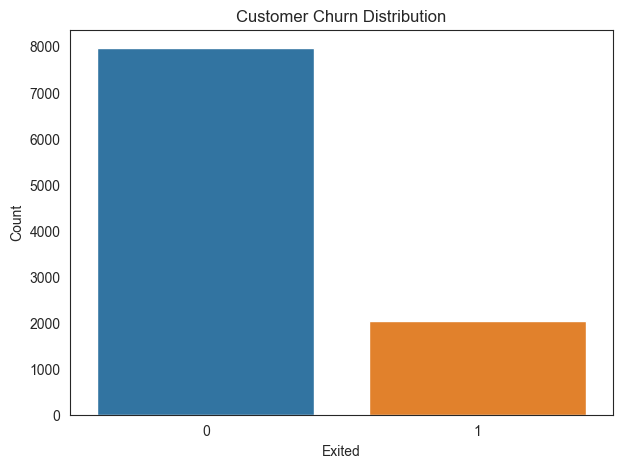

In [74]:
plt.figure(figsize=(7,5))
sns.countplot(x='Exited', data=df, palette='tab10')
plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()

Most customers stay and a smaller group leaves.


##### **2) CreditScore**

In [75]:
df['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

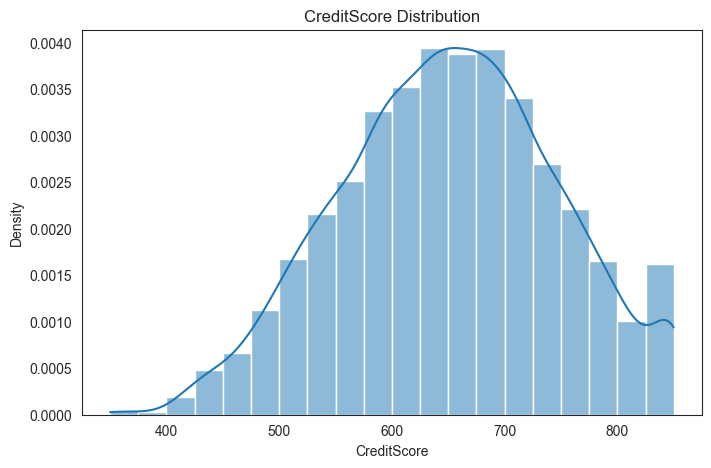

In [76]:
plt.figure(figsize=(8,5))
sns.histplot(df['CreditScore'], kde=True, bins=20, stat='density')
plt.xlabel('CreditScore')
plt.ylabel('Density')
plt.title('CreditScore Distribution')
plt.show()

Very low or very high scores are rare.


##### **3) Geography**

In [77]:
df['Geography'].value_counts().reset_index()

,Geography,count
0,France,5014
1,Germany,2509
2,Spain,2477


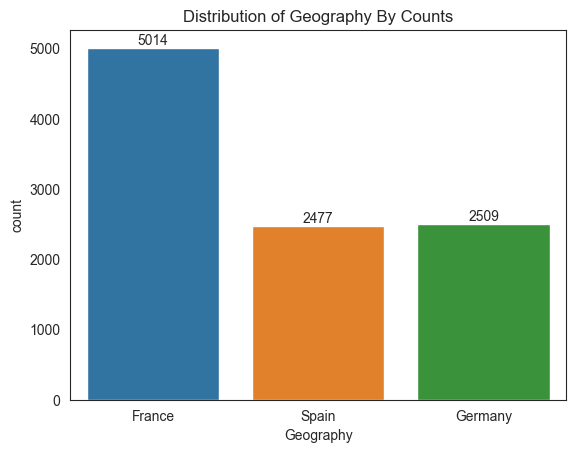

In [78]:
fig, ax = plt.subplots()
sns.countplot(x='Geography', data=df, palette='tab10', ax=ax)

# add counts on top
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])

plt.title('Distribution of Geography By Counts')
plt.show()

* Most customers are from France.
* Spain and Germany are about half as many.


##### **4) Gender**

In [79]:
df['Gender'].value_counts().reset_index()

,Gender,count
0,Male,5457
1,Female,4543


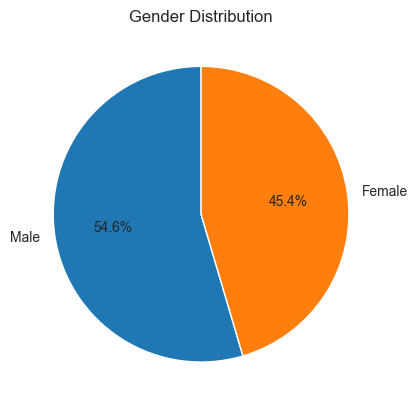

In [80]:
gender_counts = df['Gender'].value_counts()

# Pie chart
plt.pie(gender_counts, 
        labels=gender_counts.index, 
        autopct='%1.1f%%', 
        colors=plt.cm.tab10.colors,
        startangle=90)
plt.title('Gender Distribution')
plt.show()

Males are more as compared to females.


##### **5) Age**

In [81]:
df['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

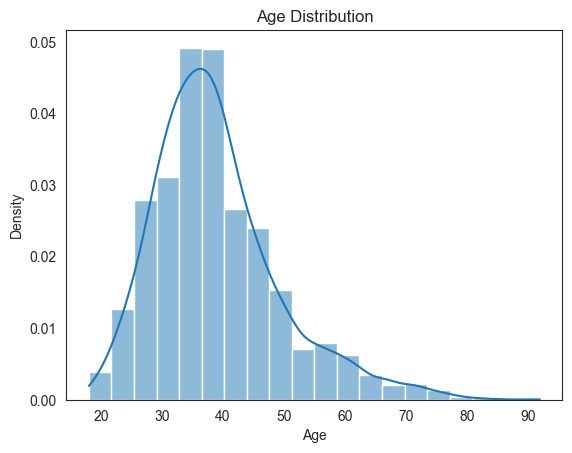

In [82]:
sns.histplot(df['Age'], kde = True, bins=20, stat='density')

plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age Distribution')
plt.show()

* Most customers are in their 30s–40s. 
* Few are very young or very old.


##### **6) Tenure**

In [83]:
# tenure is a discrete column so we will treat it like categorical columns
TenureCounts = df['Tenure'].value_counts().reset_index()
TenureCounts

,Tenure,count
0,2,1048
1,1,1035
2,7,1028
3,8,1025
4,5,1012
5,3,1009
6,4,989
7,9,984
8,6,967
9,10,490


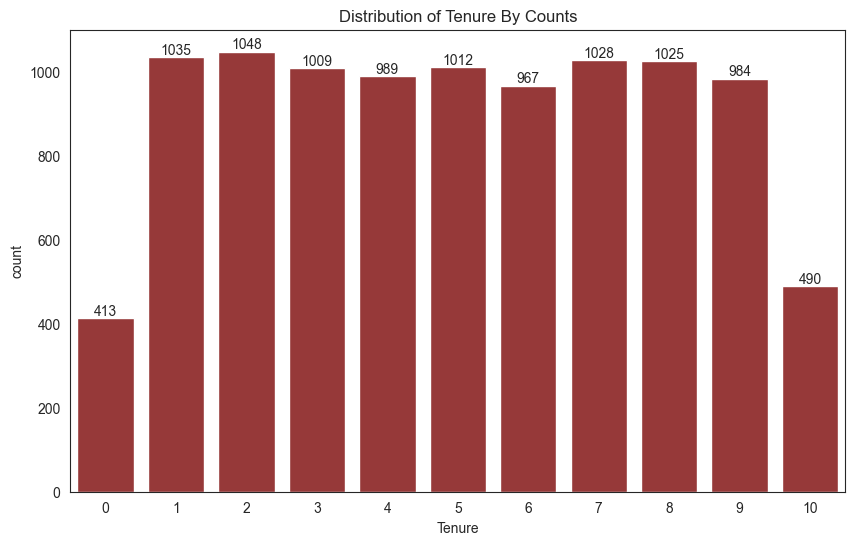

In [84]:
fig, ax = plt.subplots(figsize=(10,6)) 

# Barplot
sns.barplot(data=TenureCounts, x='Tenure', y='count', color='brown', ax=ax)

# Add counts on top of bars
ax.bar_label(ax.containers[0])

# title
plt.title('Distribution of Tenure By Counts')
plt.show()

* Many customers have 1 to 9 years tenure. 
* Very few are brand new 0 or at 10 years.



##### **7) Balance**



In [85]:
df['Balance'].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

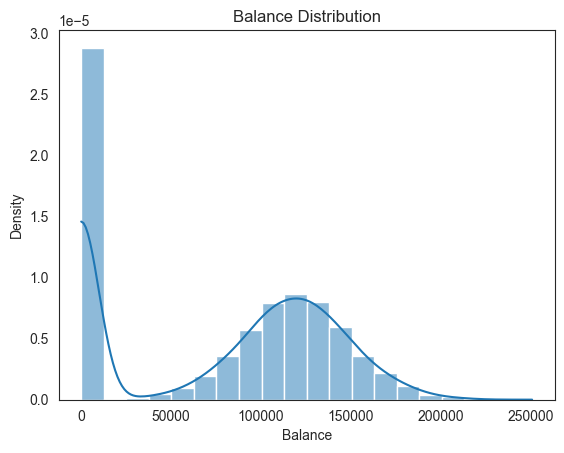

In [86]:
sns.histplot(df['Balance'], kde=True, bins=20, stat='density')

plt.title('Balance Distribution')
plt.show()

* Two groups present one with almost zero balance and another around 100k–150k.
* A bimodal distribution in the balance column suggests two distinct customer segments:

    * Low-balance customers who may be more likely to churn.
    * High-balance customers who are likely more engaged and loyal



 
 
##### **8) NumOfProducts**


In [87]:
df['NumOfProducts'].value_counts().reset_index()

,NumOfProducts,count
0,1,5084
1,2,4590
2,3,266
3,4,60


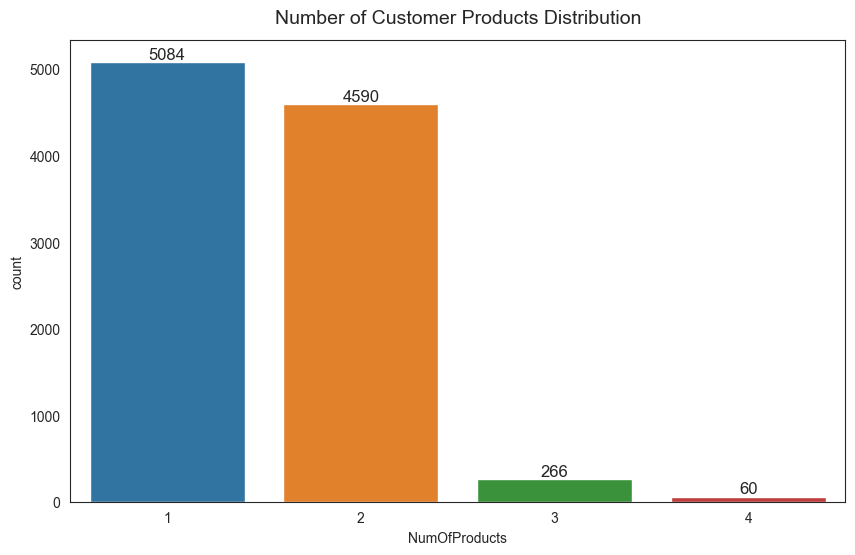

In [88]:

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x='NumOfProducts',
    palette='tab10'
)

for container in ax.containers:
    ax.bar_label(container, fontsize=12)

plt.title(
    'Number of Customer Products Distribution',
    fontsize=14,
    pad=12
)

plt.show()


* Most have 1 to 2 products. 
* Very few have 3 to 4.



##### **9) IsActiveMember**

In [89]:
df['IsActiveMember'].value_counts()


IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

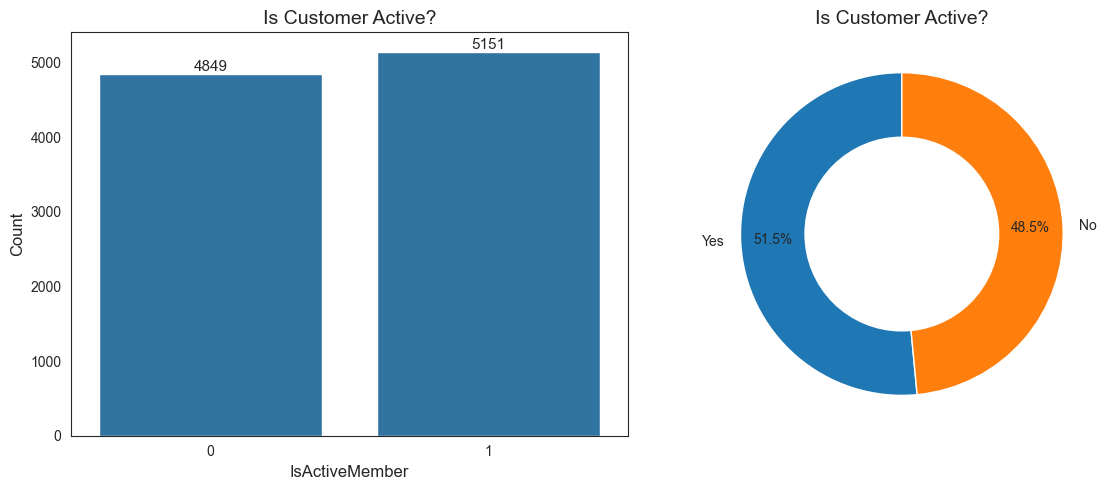

In [90]:
sns.set_style("white")
sns.set_palette("tab10")

plt.figure(figsize=(12, 5))

# Countplot
plt.subplot(1, 2, 1)
ax = sns.countplot(data=df, x='IsActiveMember')
ax.bar_label(ax.containers[0], fontsize=11)

plt.title('Is Customer Active?', fontsize=14)
plt.xlabel('IsActiveMember', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Donut chart
plt.subplot(1, 2, 2)
counts = df['IsActiveMember'].value_counts()

plt.pie(
    counts,
    labels=['Yes', 'No'],
    autopct='%1.1f%%',
    colors=plt.cm.tab10.colors,
    startangle=90,
    pctdistance=0.8
)
plt.gca().add_artist(plt.Circle((0, 0), 0.6, fc='white'))

plt.title('Is Customer Active?', fontsize=14)

plt.tight_layout()
plt.show()

Have slightly more active than inactive customers.



##### **10) EstimatedSalary**

In [91]:
df['EstimatedSalary'].describe()


count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64

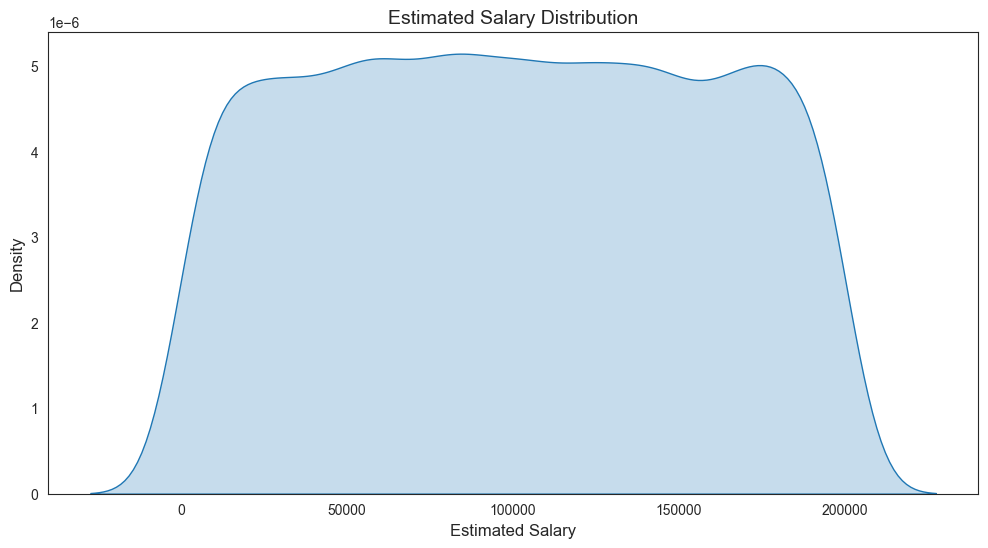

In [92]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    df['EstimatedSalary'],
    fill=True,
    color=plt.cm.tab10.colors[0]
)

plt.title('Estimated Salary Distribution', fontsize=14)
plt.xlabel('Estimated Salary', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.show()

Spread evenly across the range and no clear peak.


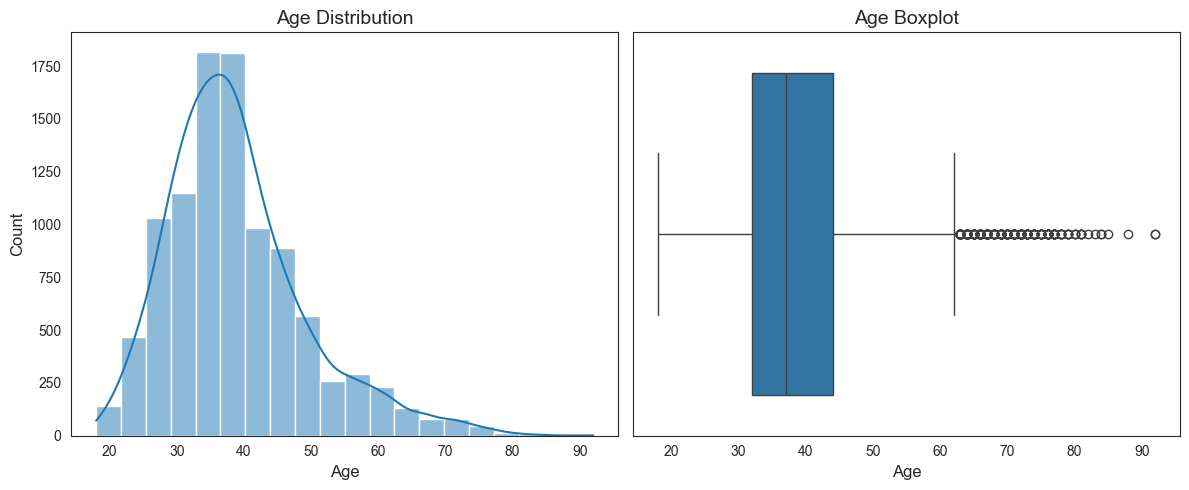

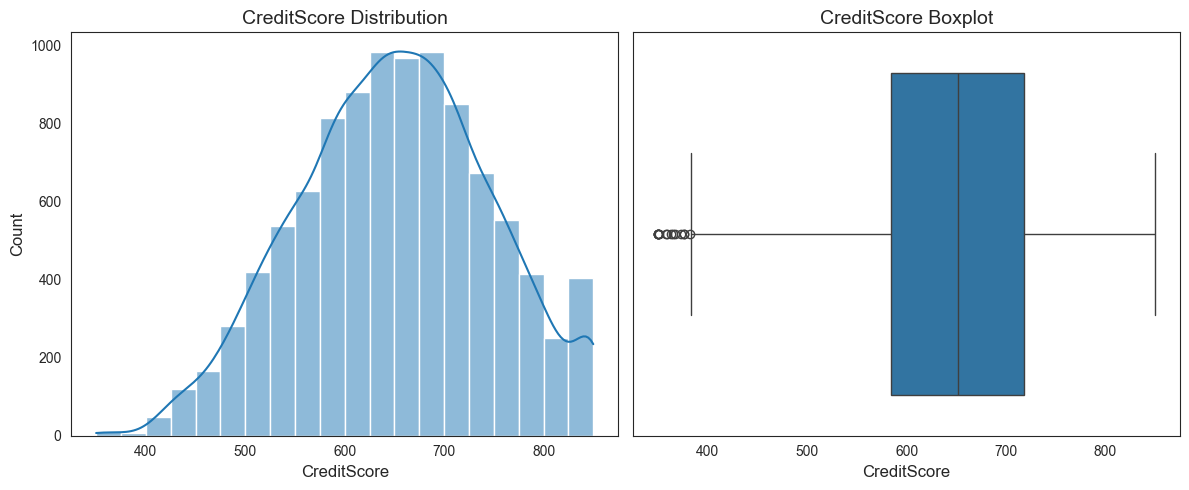

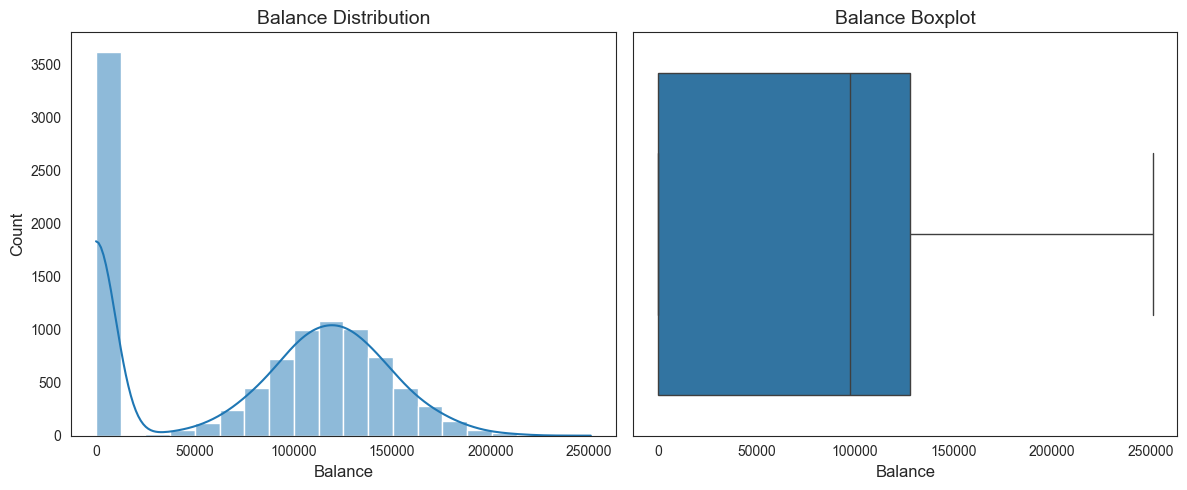

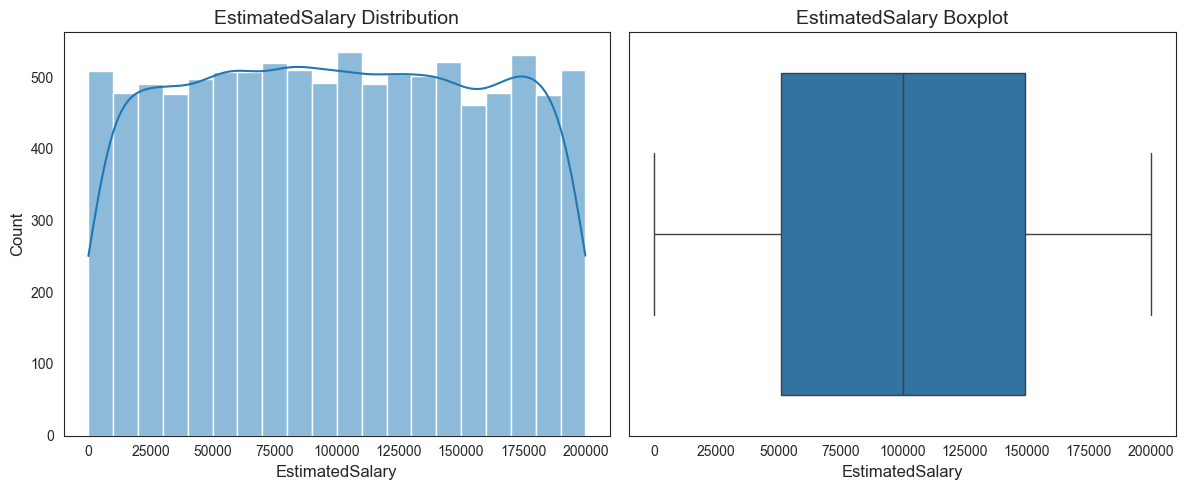

In [93]:
cont_col = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']

sns.set_style("white")
sns.set_palette("tab10")

for col in cont_col:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'{col} Distribution', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot', fontsize=14)
    plt.xlabel(col, fontsize=12)

    plt.tight_layout()
    plt.show()

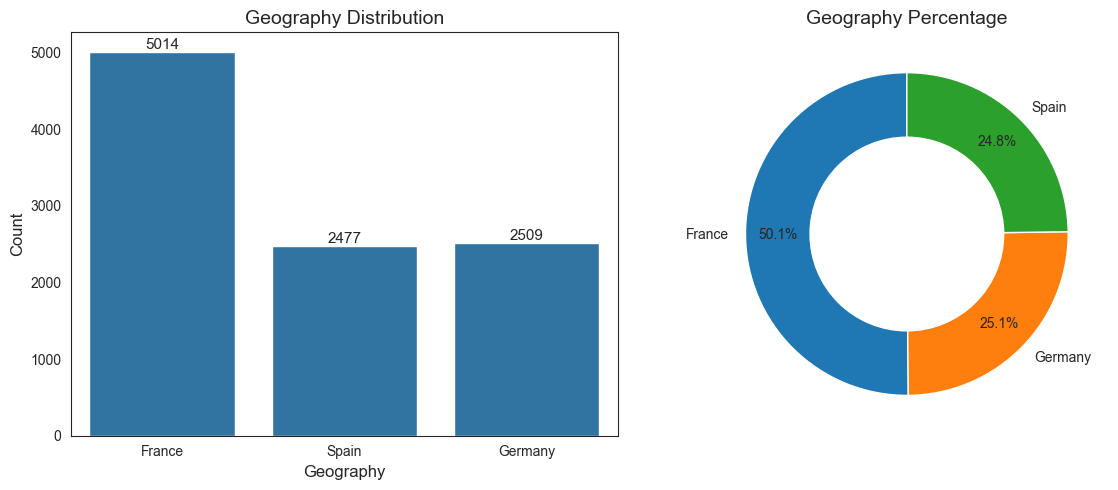

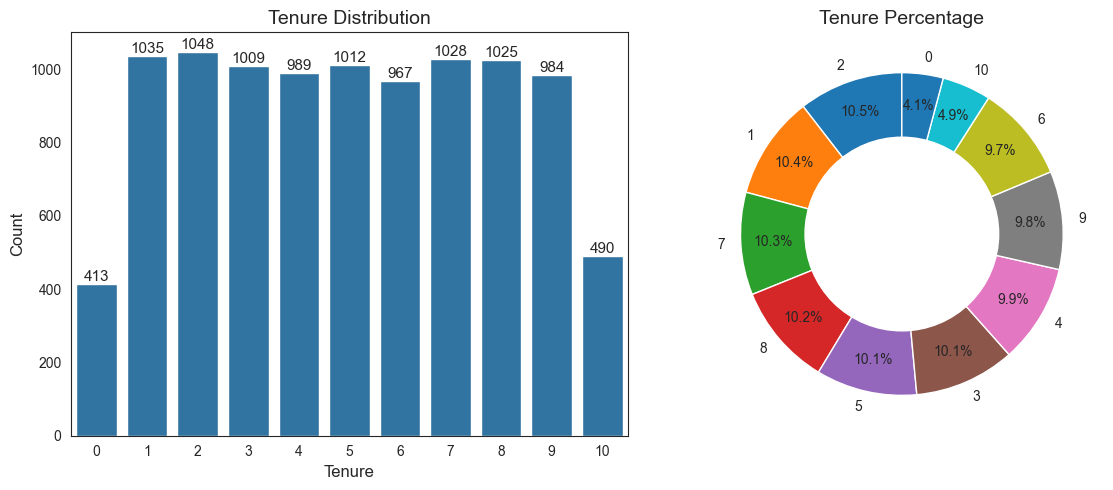

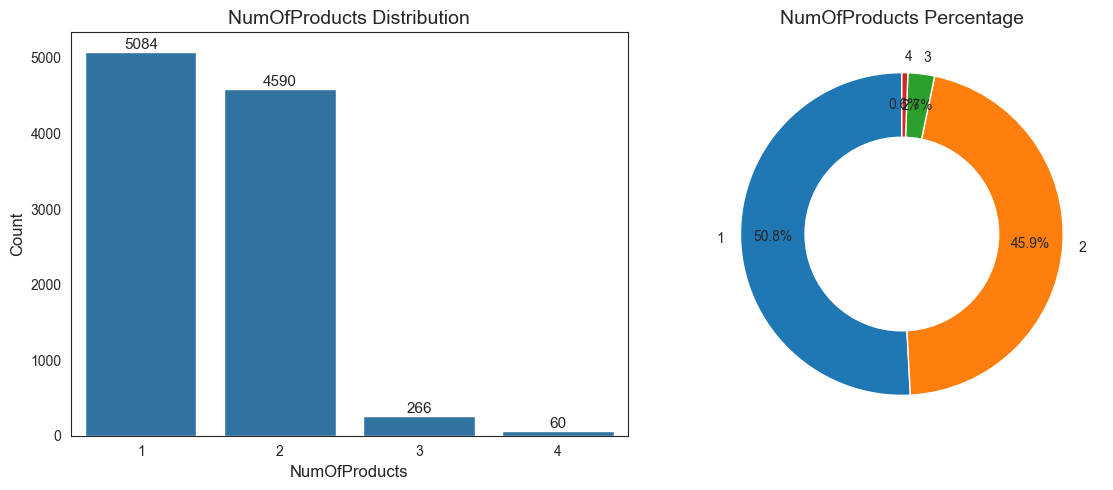

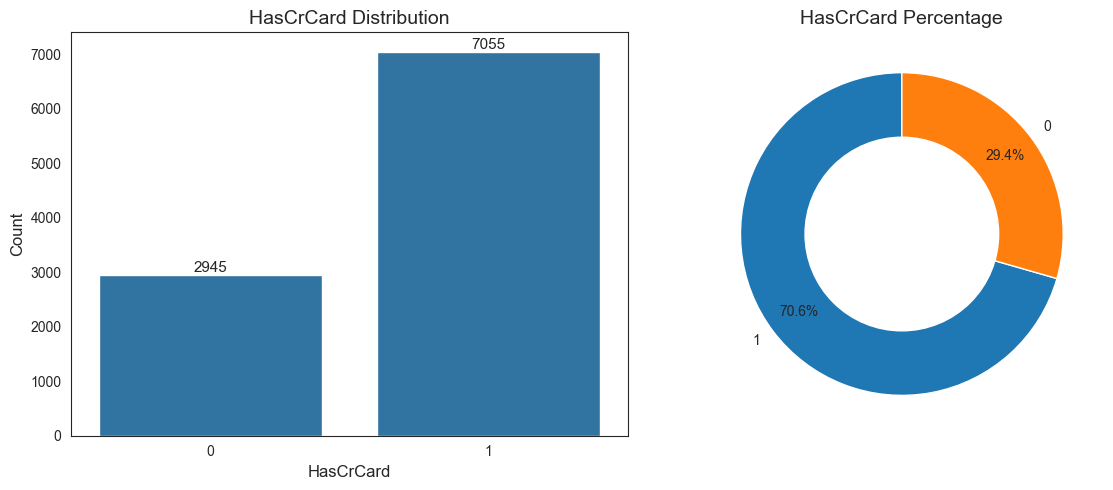

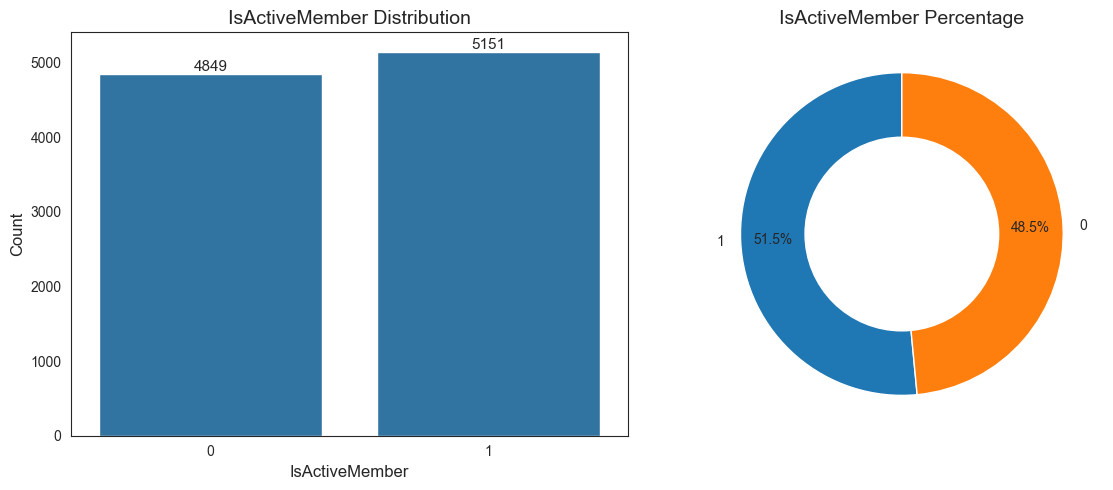

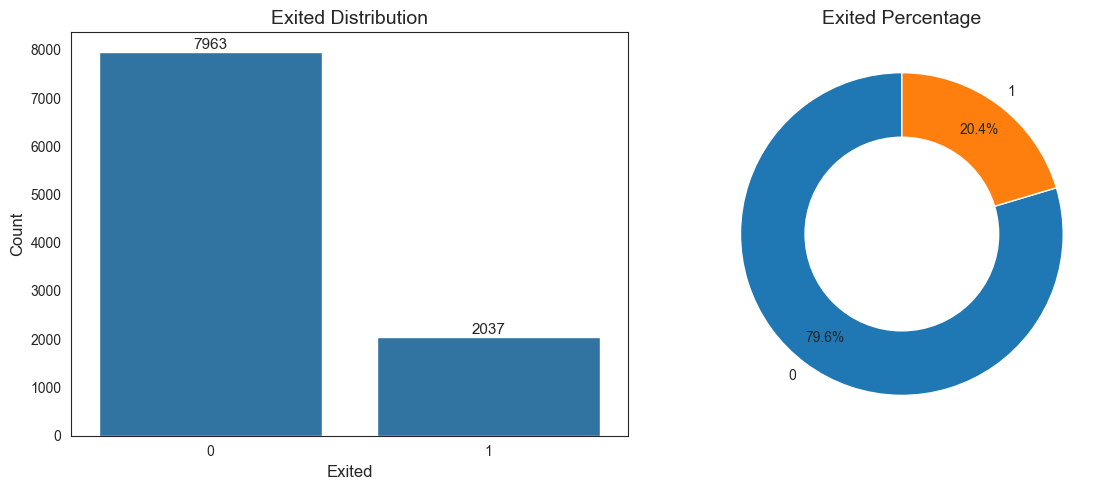

In [94]:
cat_col = ['Geography', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']

sns.set_style("white")
sns.set_palette("tab10")

for col in cat_col:
    count = df[col].value_counts()

    plt.figure(figsize=(12, 5))

    # Countplot
    plt.subplot(1, 2, 1)
    ax = sns.countplot(data=df, x=col)
    ax.bar_label(ax.containers[0], fontsize=11)

    plt.title(f'{col} Distribution', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)

    # Donut chart (cleaner than pie)
    plt.subplot(1, 2, 2)
    plt.pie(
        count.values,
        labels=count.index,
        autopct='%1.1f%%',
        colors=plt.cm.tab10.colors,
        startangle=90,
        pctdistance=0.8
    )
    plt.gca().add_artist(plt.Circle((0, 0), 0.6, fc='white'))

    plt.title(f'{col} Percentage', fontsize=14)

    plt.tight_layout()
    plt.show()

* Most customers have a credit card about 29% do not.
* Around 20% left, 80% stayed.
 

In [95]:
cont_col = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']

df.groupby('Exited')[cont_col].median().reset_index().T

,0,1
Exited,0.00,1.00
Age,36.00,45.00
CreditScore,653.00,646.00
Balance,92072.68,109349.29
EstimatedSalary,99645.04,102460.84


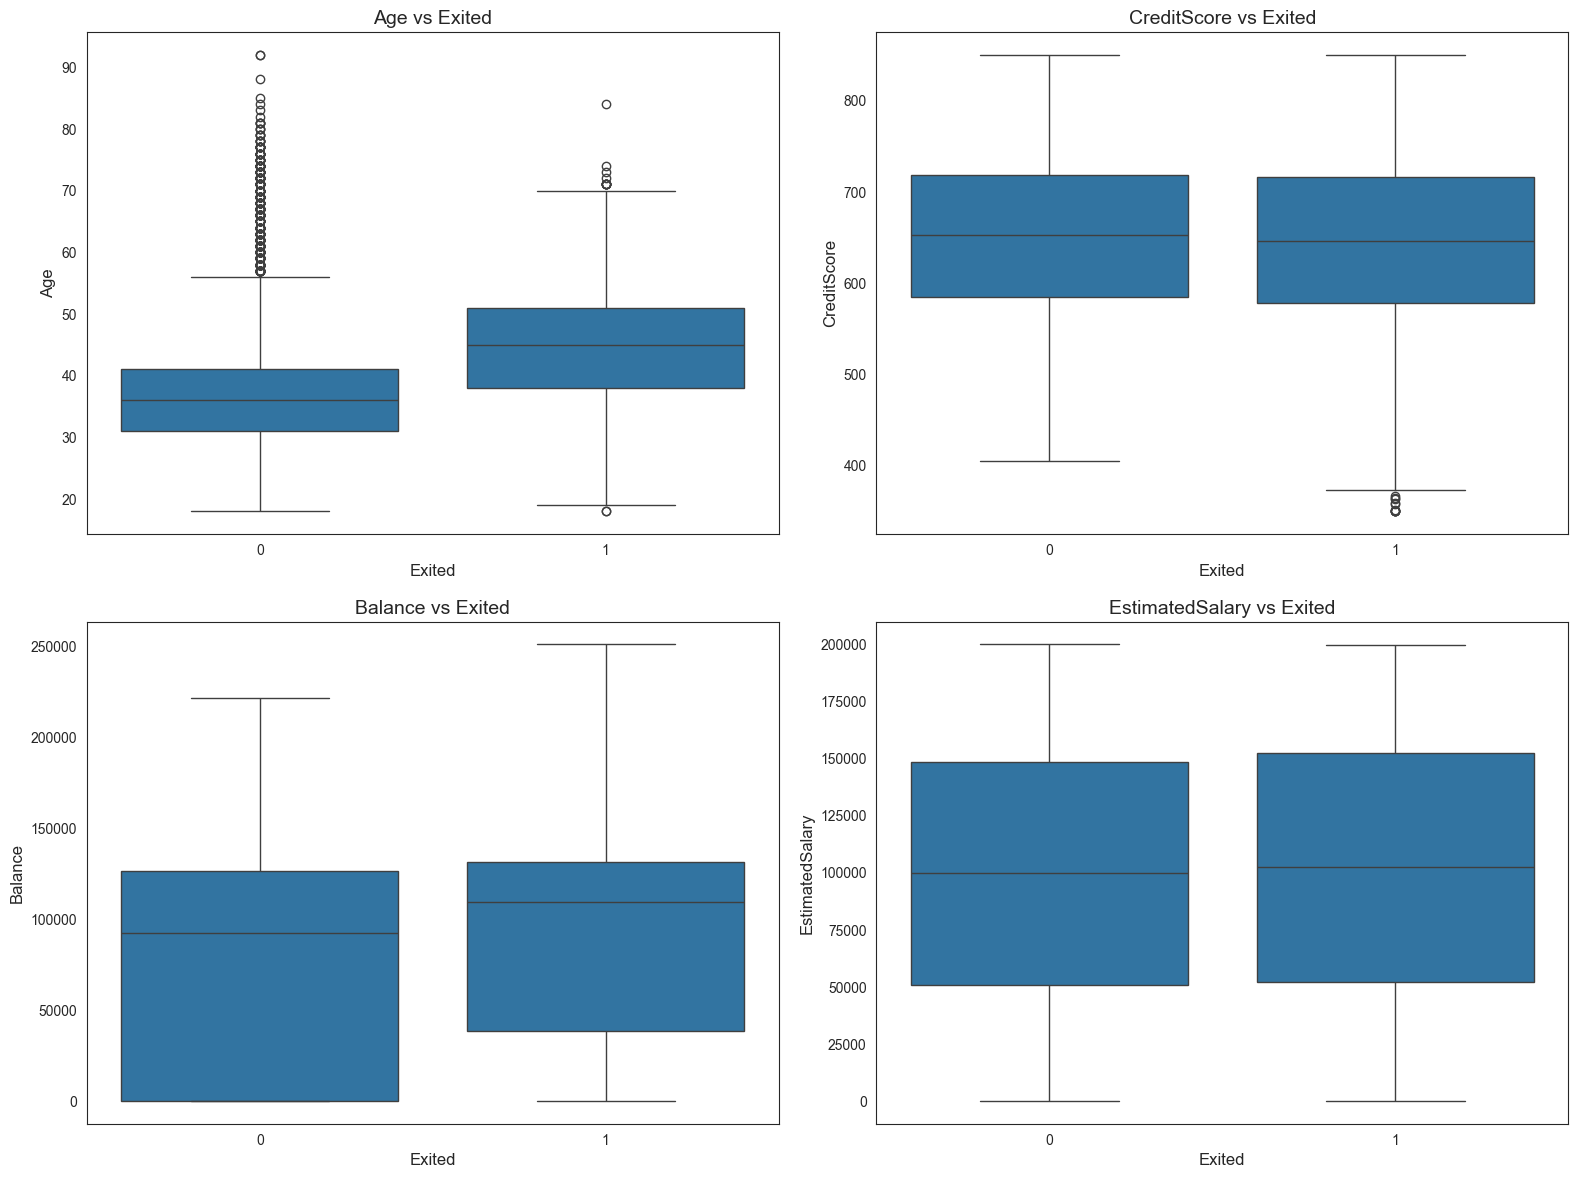

In [96]:
cont_col = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']

# Consistent style with previous plots
sns.set_style("white")
sns.set_palette("tab10")

plt.figure(figsize=(16, 12))

for i, col in enumerate(cont_col, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Exited', y=col, data=df)

    plt.title(f'{col} vs Exited', fontsize=14)
    plt.xlabel('Exited', fontsize=12)
    plt.ylabel(col, fontsize=12)

plt.tight_layout(pad=1.5)
plt.show()

* Leavers tend to be older.
  
* Credit scores and estimated salary look similar for leavers vs stayers.
  
* Leavers often have higher balances.

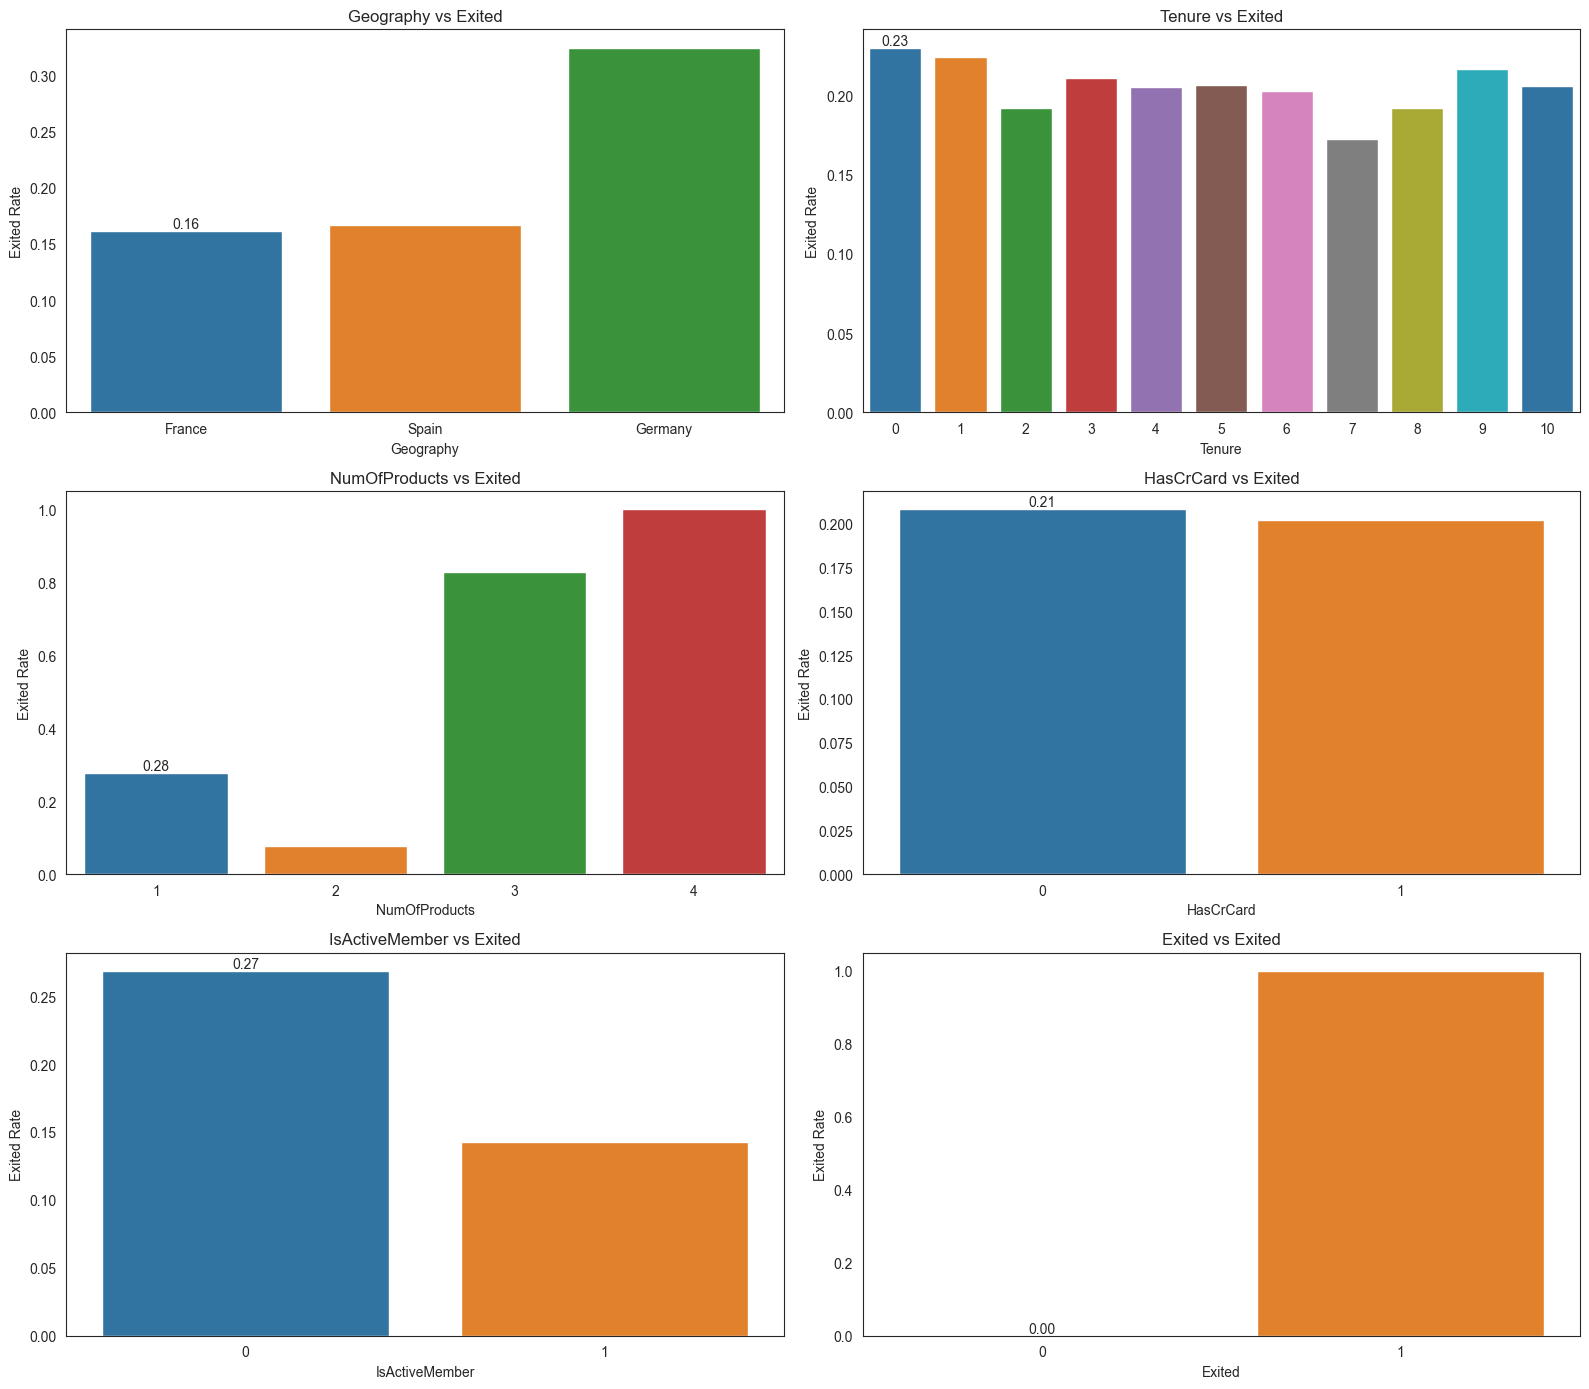

In [97]:
plt.figure(figsize=(16, 14))

for i, col in enumerate(cat_col, 1):
    ax = plt.subplot(3, 2, i)
    sns.barplot(x=col, y='Exited', data=df, estimator='mean', errorbar=None, palette='tab10')

    ax.bar_label(ax.containers[0], fmt='%.2f')
    ax.set_title(f'{col} vs Exited')
    ax.set_ylabel('Exited Rate')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

* Germany has the highest churn, France the lowest.
  
* Tenure doesn’t change churn much.

* Having 3 to 4 products is linked to much higher churn and 2 products has the lowest churn.
  
* Having a credit card doesn’t affect churn much.
  
* Active members churn less.


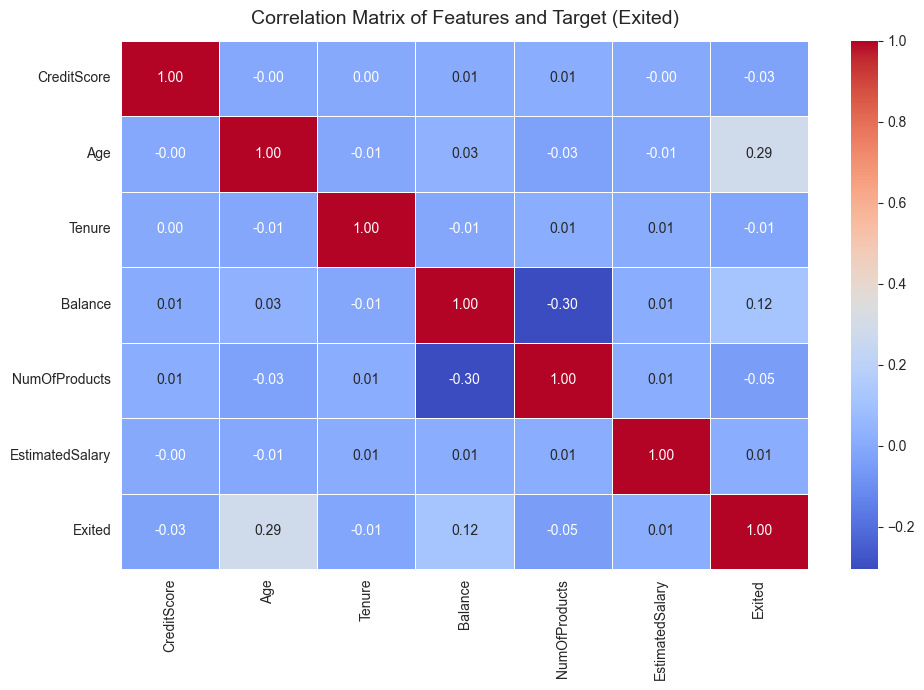

In [98]:
cols_correlation = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'EstimatedSalary', 'Exited'
]

corr = df[cols_correlation].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.4,
    annot_kws={'size': 10}
)

plt.title(
    'Correlation Matrix of Features and Target (Exited)',
    fontsize=14,
    pad=12
)

plt.xticks()
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

* Age has the strongest positive link to churn and balance has a small positive link.
  
* More products is negatively related to balance those with more products would have lower balances.
  
* Other features show very weak or no correlation with churn.

### **Data Preprocessing** 

In [99]:
# identify categorical columns
cat_cols = ['Geography', 'Gender']

ct = ColumnTransformer(
    transformers=[
        ('geo', OneHotEncoder(drop='first'), ['Geography']),  # for Geography
        ('gender', OneHotEncoder(drop='if_binary'), ['Gender'])  # for Gender
    ],
    remainder='passthrough'
)

In [100]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X = ct.fit_transform(X)


In [101]:

# get feature names after one-hot encoding
geo_features = ct.named_transformers_['geo'].get_feature_names_out(['Geography'])
num_features = df.drop(['Geography', 'Exited'], axis=1).columns
feature_names = list(geo_features) + list(num_features)

In [102]:
feature_names

['Geography_Germany',
 'Geography_Spain',
 'CreditScore',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [103]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [104]:
# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [105]:
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 8000
Test size: 2000


### **Model Training and Evaluation** 

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import pandas as pd
import joblib

In [107]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(verbose=0)
}




========== Logistic Regression ==========


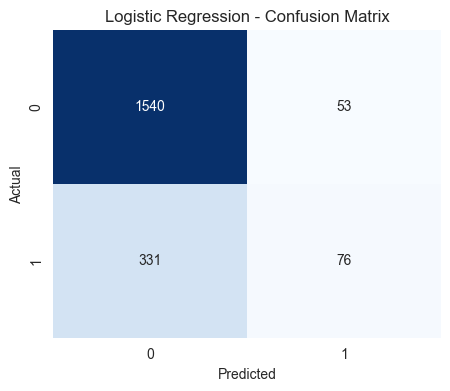

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


========== SVM ==========


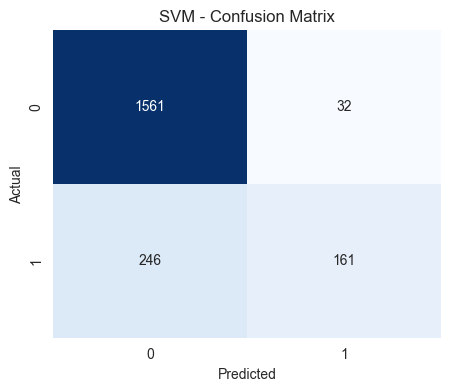

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1593
           1       0.83      0.40      0.54       407

    accuracy                           0.86      2000
   macro avg       0.85      0.69      0.73      2000
weighted avg       0.86      0.86      0.84      2000


========== Random Forest ==========


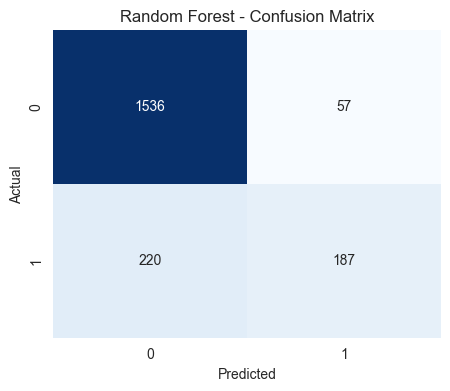

              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1593
           1       0.77      0.46      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000


========== Gradient Boosting ==========


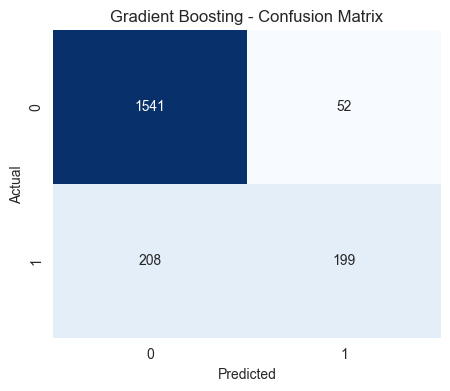

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000


========== XGBoost ==========


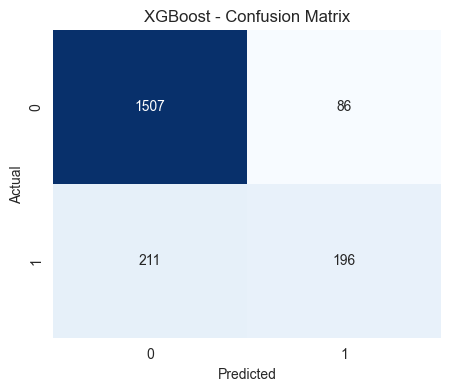

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1593
           1       0.70      0.48      0.57       407

    accuracy                           0.85      2000
   macro avg       0.79      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000


========== CatBoost ==========


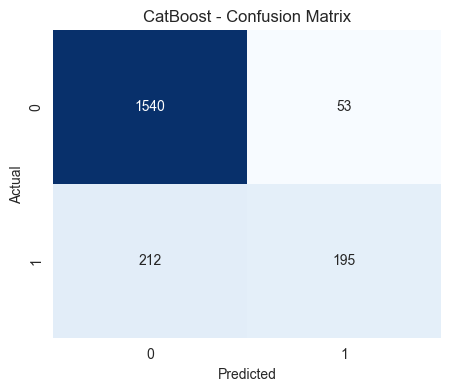

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000


=== Model Comparison Sorted by F1-Score ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC_AUC
3,Gradient Boosting,0.8700,0.792829,0.488943,0.604863,0.870831
5,CatBoost,0.8675,0.786290,0.479115,0.595420,0.861365
2,Random Forest,0.8615,0.766393,0.459459,0.574501,0.850198
4,XGBoost,0.8515,0.695035,0.481572,0.568940,0.839255
1,SVM,0.8610,0.834197,0.395577,0.536667,0.826927
0,Logistic Regression,0.8080,0.589147,0.186732,0.283582,0.774778


In [108]:
results = []
best_model = None
best_f1 = 0
best_model_name = ""

for name, model in models.items():
    print(f"\n{'='*10} {name} {'='*10}")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # Classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    print(classification_report(y_test, y_pred))
    
    # Extract metrics for class 1
    f1 = report['1']['f1-score']
    precision = report['1']['precision']
    recall = report['1']['recall']
    
    # Accuracy & ROC-AUC
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    # Store metrics in results (no trained model object here)
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC_AUC": roc
    })
    
    # Keep track of best model separately
    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_model_name = name

# Create results DataFrame (metrics only)
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-Score", ascending=False)

print("\n=== Model Comparison Sorted by F1-Score ===")
results_df


In [109]:
print(y_test.value_counts())


Exited
0    1593
1     407
Name: count, dtype: int64


In [ ]:

# Save the trained best model and transformers
print(f"\n=== Best Model Selected: {best_model_name} ===")
joblib.dump(best_model, "best_churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(ct, "column_transformer.pkl")


=== Best Model Selected: Gradient Boosting ===


['column_transformer.pkl']

In [113]:

results_df.to_csv('result_df.csv', index=False)

In [111]:
import sklearn
print(sklearn.__version__)

1.7.2


In [112]:
import joblib
print(joblib.__version__)

1.5.2


## **Conclusion  and Insights**

This analysis highlights clear patterns in customer churn and actionable strategies for the bank:

* **Customer Profile:** Older customers with higher balances are more likely to leave. Geography matters Germany has the highest churn, France the lowest. Gender has minimal impact.
  
* **Products & Engagement:** Customers with 3-4 products churn more, while 1-2 product holders are more loyal. Active members stay longer and having a credit card has minimal effect.
* **Financials:** Credit scores and salaries are similar across leavers and stayers. Balance shows a slight positive correlation with churn.
* **Model Performance:** The **Gradient Boosting model** achieved:

  * **Accuracy:** 87%
  * **Precision (churn):** 0.79
  * **Recall (churn):** 0.48
  * **F1-score (churn):** 0.60
    Age, Balance, and Number of Products are the top predictors influencing churn.

**Business Takeaways:**

* Focus retention efforts on older, high-balance customers and those with multiple products.
* Boost engagement programs for inactive members.
* Target regions with higher churn rates for marketing campaigns.
* Use the predictive Gradient Boosting model to identify at-risk customers proactively.

